# VRP Tradable Iron-Condor — Backtest Findings

**What this is.** The shipped VRP layer *measures* whether rich single-name vol is
sellable by sector. This notebook takes the next step: it turns that signal into an
actual **defined-risk iron condor** (sell 16Δ strangle + buy 8Δ wings) and backtests
it model-repriced, hold-to-expiry, across three horizons — answering *"if we had
traded this, what would have happened?"*

**Two corrections over the first cut shown in chat:**

1. **Entry-spacing.** The naive engine opens a condor on *every* RICH day, so a name
   that stays rich for weeks contributes dozens of overlapping positions — inflating
   trade counts and total-$ into something untradeable. The **spaced** path
   (`select_non_overlapping`) trades a name **only when flat** (a new entry must open
   strictly after the prior position expired). Positions across *different* names may
   still overlap — that is a real portfolio of condors.
2. **Multi-horizon.** We run hold = **5 / 20 / 60** trading days to show the
   harvest-decay curve, not just the T+20 headline.

**Honest caveats (read before trusting any dollar figure):**

- **Flat-vol modeled credit (no skew).** Strikes and entry credit are priced off a
  single ATM IV via Black–Scholes. Real condor credits carry skew, so *absolute
  dollars are approximate* — the *direction and ranking* are the signal. Real-fill
  validation needs the forward-NBBO recorder (deferred).
- **Model-repriced settlement.** Each trade settles against the corporate-action-
  adjusted realized price `hold_days` forward — model-free at exit, but entry pricing
  is the model.
- **`scope='full'` has mild lookahead** (it gates on the *final* sector verdict over
  the same window). **`scope='holdout'` (latest 40%) is the honest headline.**
- **Per-ticker gate.** A name is only tradable if its sector's RICH bucket is
  `HARVEST_SELLABLE` *and* it has an earnings calendar (so the earnings-exclusion is
  real). v1 = single-name only.

> SELECT-only on inputs. Computes in-memory; does not mutate the DB.

In [1]:
import pathlib
import sys

# Make `uw_scan` importable whether run from the repo root (nbconvert) or from
# docs/research/vrp/ (jupyter lab) — walk up to the dir holding pyproject.toml.
_here = pathlib.Path.cwd()
for _p in (_here, *_here.parents):
    if (_p / "pyproject.toml").exists():
        sys.path.insert(0, str(_p / "src"))
        break

import os

import matplotlib.pyplot as plt
import pandas as pd
import psycopg
from pydantic import SecretStr

from uw_scan.cards.skew_first_principles import asset_class_baseline
from uw_scan.config import Settings
from uw_scan.reports.vrp_backtest import (
    _sellable_sectors,
    backtest_ticker,
    select_non_overlapping,
)
from uw_scan.reports.vrp_structure import CostModel
from uw_scan.storage.repository import Repository

dsn = (
    f"host={os.environ.get('UW_SCAN_DB_HOST', '127.0.0.1')} "
    f"dbname={os.environ.get('UW_SCAN_DB_NAME', 'option_wizard_local')} "
    f"user={os.environ.get('UW_SCAN_DB_USER', 'chenxi')}"
)
conn = psycopg.connect(dsn)
repo = Repository(conn)

# Trade structure / cost knobs come straight from Settings defaults (the same values
# the production scheduler job uses), so the notebook can't silently diverge.
s = Settings(api_key=SecretStr("notebook"))
SHORT_D, WING_D, R = s.vrp_short_delta, s.vrp_wing_delta, s.vrp_risk_free_rate
COST = CostModel(
    s.vrp_cost_per_contract,
    s.vrp_slippage_frac,
    s.vrp_slippage_min,
    round_trip=s.vrp_cost_round_trip,
)
HORIZONS = [5, 20, 60]
print(f"connected: {dsn}")
print(
    f"structure: sell {SHORT_D:.0%}Δ / buy {WING_D:.0%}Δ condor, r={R:.0%}, "
    f"cost/contract=${s.vrp_cost_per_contract}, slippage={s.vrp_slippage_frac:.0%}"
)

connected: host=127.0.0.1 dbname=option_wizard_local user=chenxi
structure: sell 16%Δ / buy 8%Δ condor, r=4%, cost/contract=$0.65, slippage=1%


## 1 — Run the backtest (eligible universe × 3 horizons × naive/spaced)

The eligibility gate mirrors `run_vrp_backtest` exactly: single-name asset class, a
`HARVEST_SELLABLE` RICH sector bucket, and a non-empty earnings calendar.

In [2]:
import time

sellable = _sellable_sectors(repo)


def eligible(repo, sellable):
    out = []
    for tk in repo.fetch_distinct_vrp_tickers():
        sector = repo.fetch_watchlist_sector(tk)
        if asset_class_baseline(tk, sector=sector)["asset_class"] != "single_name":
            continue
        if (sector or "unknown") not in sellable:
            continue
        if not repo.fetch_historical_earnings_dates(tk):
            continue
        out.append((tk, sector or "unknown"))
    return out


units = eligible(repo, sellable)
rows = []
t0 = time.time()
for hd in HORIZONS:
    for tk, sector in units:
        naive = backtest_ticker(
            repo, tk, hold_days=hd, short_delta=SHORT_D, wing_delta=WING_D,
            r=R, cost_model=COST,
        )
        if not naive:
            continue
        spaced = select_non_overlapping(naive)
        # NB: column is "book" not "mode" — `df.mode` collides with the
        # DataFrame.mode() method, so `trades.mode == ...` would compare a bound
        # method to a string (always False). Use a non-colliding name + brackets.
        for book, ts in (("naive", naive), ("spaced", spaced)):
            for t in ts:
                rows.append(
                    dict(
                        ticker=tk, sector=sector, horizon=hd, book=book,
                        entry_date=t.entry_date, expiry_date=t.expiry_date,
                        net_pnl=t.net_pnl, return_on_risk=t.return_on_risk,
                        breached=t.breached, in_holdout=t.in_holdout,
                        entry_credit=t.entry_credit, max_loss=t.max_loss,
                    )
                )

trades = pd.DataFrame(rows)
print(
    f"{len(units)} eligible single-name tickers across {len(sellable)} SELLABLE "
    f"sectors\n{len(trades):,} trade-rows computed in {time.time() - t0:.1f}s"
)
print(
    "input window:",
    trades["entry_date"].min(),
    "→",
    trades["expiry_date"].max(),
)
print("sellable sectors:", ", ".join(sorted(sellable)))

82 eligible single-name tickers across 15 SELLABLE sectors
9,448 trade-rows computed in 0.8s
input window: 2025-07-11 → 2026-06-15
sellable sectors: Banks, Consumer, Crypto, Energy, Fintech, Foundry, Healthcare, M7, Memory, NeoCloud, Power, SaaS, Semi-Cap, Space, unknown


## 2 — The overlap correction: naive vs entry-spaced

Same signal, same costs — the only difference is whether we re-enter a name while a
position is still open. Spacing collapses the trade count and the headline P&L to
something you could actually hold. **`holdout` is the honest column.**

In [3]:
def summ(df):
    n = len(df)
    if n == 0:
        return dict(n=0, win=None, total=None, mean=None, ror=None, breach=None)
    net = df["net_pnl"]
    return dict(
        n=n,
        win=(net > 0).mean(),
        total=net.sum(),
        mean=net.mean(),
        ror=df["return_on_risk"].mean(),
        breach=df["breached"].mean(),
    )


def scoped(df, scope):
    return df if scope == "full" else df[df["in_holdout"]]


recs = []
for hd in HORIZONS:
    for book in ("naive", "spaced"):
        for scope in ("full", "holdout"):
            d = scoped(
                trades[(trades["horizon"] == hd) & (trades["book"] == book)], scope
            )
            r = summ(d)
            r.update(horizon=hd, book=book, scope=scope)
            recs.append(r)

overview = pd.DataFrame(recs)[
    ["horizon", "book", "scope", "n", "win", "total", "mean", "ror", "breach"]
]


def _f(spec):
    # None-safe formatter: empty cell for missing metrics (zero-trade combos).
    def g(v):
        return "" if v is None or pd.isna(v) else spec.format(v)

    return g


fmt = {
    "win": _f("{:.0%}"),
    "breach": _f("{:.0%}"),
    "total": _f("${:,.0f}"),
    "mean": _f("${:,.0f}"),
    "ror": _f("{:+.3f}"),
}
overview.style.format(fmt).hide(axis="index")

horizon,book,scope,n,win,total,mean,ror,breach
5,naive,full,3668,58%,"$-65,886",$-18,-0.171,25%
5,naive,holdout,1469,61%,"$-32,446",$-22,-0.145,25%
5,spaced,full,962,55%,"$-37,675",$-39,-0.213,28%
5,spaced,holdout,383,58%,"$-11,265",$-29,-0.184,28%
20,naive,full,2913,70%,"$215,189",$74,-0.050,24%
20,naive,holdout,1164,72%,"$110,883",$95,-0.029,23%
20,spaced,full,401,65%,"$6,853",$17,-0.096,29%
20,spaced,holdout,163,66%,"$-1,491",$-9,-0.105,33%
60,naive,full,1398,66%,"$-5,252",$-4,-0.094,35%
60,naive,holdout,562,72%,"$87,840",$156,-0.036,30%


## 3 — Equity curve (T+20, 1 contract per signal)

Cumulative realized net P&L plotted by **realization (expiry) date**. The grey line is
the naive overlapping book; the green line is the entry-spaced book you could actually
run. The gap between them is the overlap inflation.

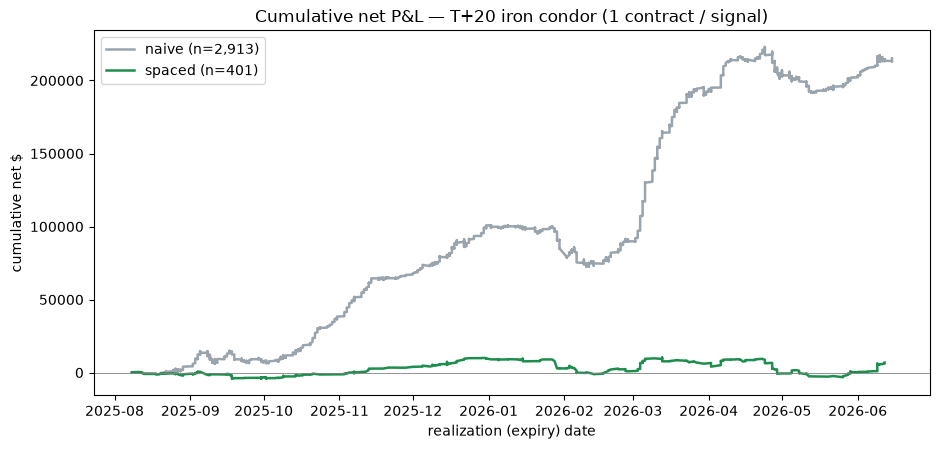

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for book, color in (("naive", "#9aa4ad"), ("spaced", "#1e8e4e")):
    d = trades[(trades["horizon"] == 20) & (trades["book"] == book)].sort_values(
        "expiry_date"
    )
    if d.empty:
        continue
    ax.plot(
        pd.to_datetime(d["expiry_date"]),
        d["net_pnl"].cumsum(),
        label=f"{book} (n={len(d):,})",
        color=color,
        lw=1.8,
    )
ax.axhline(0, color="gray", lw=0.6)
ax.set_title("Cumulative net P&L — T+20 iron condor (1 contract / signal)")
ax.set_ylabel("cumulative net $")
ax.set_xlabel("realization (expiry) date")
ax.legend()
plt.tight_layout()
plt.show()

## 4 — Harvest decay across horizons (entry-spaced)

How the spaced book's total P&L and win-rate move as we hold longer. Short holds turn
over fast (more trades, thinner credit); long holds collect more premium per trade but
carry more breach risk.

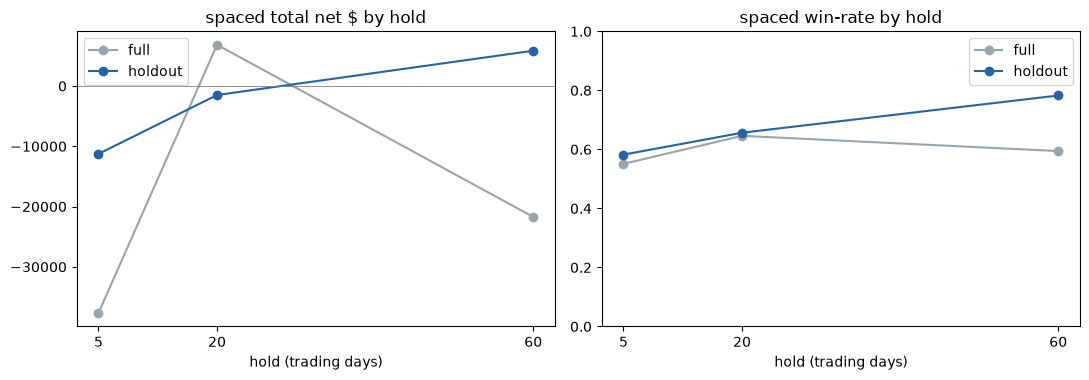

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.9))
for scope, c in (("full", "#9aa4ad"), ("holdout", "#2563a8")):
    sub = overview[
        (overview["book"] == "spaced") & (overview["scope"] == scope)
    ].sort_values("horizon")
    a1.plot(sub["horizon"], sub["total"], marker="o", label=scope, color=c)
    a2.plot(sub["horizon"], sub["win"], marker="o", label=scope, color=c)
a1.axhline(0, color="gray", lw=0.6)
a1.set_title("spaced total net $ by hold")
a1.set_xlabel("hold (trading days)")
a1.set_xticks(HORIZONS)
a1.legend()
a2.set_title("spaced win-rate by hold")
a2.set_xlabel("hold (trading days)")
a2.set_xticks(HORIZONS)
a2.set_ylim(0, 1)
a2.legend()
plt.tight_layout()
plt.show()

## 5 — Where the edge lives: by sector (entry-spaced, holdout, T+20)

The gate already restricts to SELLABLE sectors; this ranks *how well* each held up
out-of-sample once spacing is applied. Green = positive holdout $, red = negative.

sector,n,win,total,mean,breach
Memory,4,75%,"$4,193","$1,048",25%
NeoCloud,11,82%,"$1,188",$108,18%
Power,4,75%,"$1,110",$278,25%
unknown,24,67%,$827,$34,29%
Space,10,80%,$764,$76,20%
Healthcare,15,53%,$705,$47,20%
Crypto,9,56%,$200,$22,33%
Fintech,4,50%,$85,$21,25%
Energy,4,75%,$-85,$-21,25%
Consumer,15,67%,$-957,$-64,27%


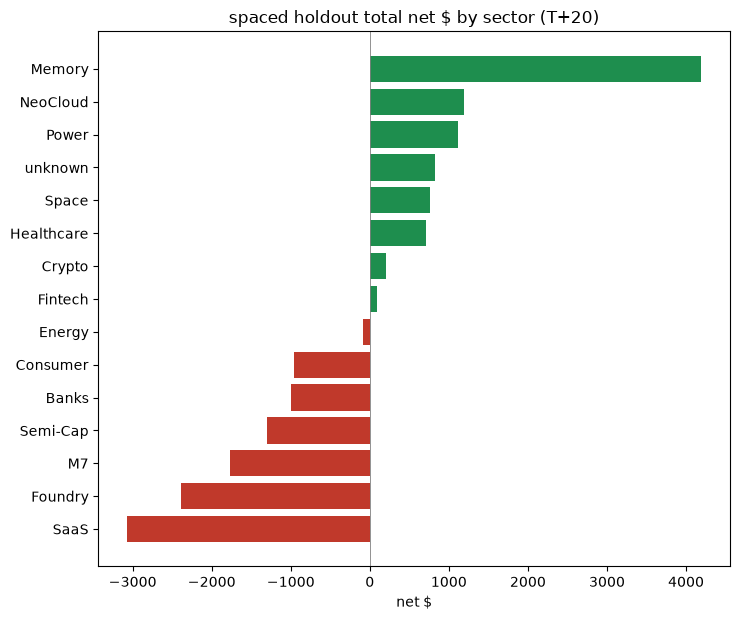

In [6]:
base = trades[
    (trades["horizon"] == 20)
    & (trades["book"] == "spaced")
    & (trades["in_holdout"])
]
sec_recs = []
for sector, d in base.groupby("sector"):
    r = summ(d)
    r["sector"] = sector
    sec_recs.append(r)
sectors = pd.DataFrame(sec_recs).sort_values("total", ascending=False)
display(
    sectors[["sector", "n", "win", "total", "mean", "breach"]]
    .style.format(fmt)
    .hide(axis="index")
)

ss = sectors.sort_values("total")
colors = ["#1e8e4e" if v > 0 else "#c0392b" for v in ss["total"]]
fig, ax = plt.subplots(figsize=(7.5, max(4, 0.42 * len(ss))))
ax.barh(ss["sector"], ss["total"], color=colors)
ax.axvline(0, color="gray", lw=0.6)
ax.set_title("spaced holdout total net $ by sector (T+20)")
ax.set_xlabel("net $")
plt.tight_layout()
plt.show()

## 6 — Per-ticker (entry-spaced, holdout, T+20)

This is the per-name extensibility the build was about: edge gated at the sector, but
trades and P&L keyed per ticker. Top and bottom 12 by holdout net $.

In [7]:
tk_recs = []
for tk, d in base.groupby("ticker"):
    r = summ(d)
    r["ticker"] = tk
    tk_recs.append(r)
tickers = pd.DataFrame(tk_recs).sort_values("total", ascending=False)
cols = ["ticker", "n", "win", "total", "mean", "breach"]
print("TOP 12 (holdout net $)")
display(tickers.head(12)[cols].style.format(fmt).hide(axis="index"))
print("BOTTOM 12 (holdout net $)")
display(tickers.tail(12)[cols].style.format(fmt).hide(axis="index"))

TOP 12 (holdout net $)


ticker,n,win,total,mean,breach
SNDK,2,100%,"$6,538","$3,269",0%
BLK,2,100%,"$1,724",$862,0%
BE,2,100%,"$1,173",$587,0%
ISRG,3,100%,"$1,149",$383,0%
TSLA,2,100%,"$1,147",$573,0%
TER,2,100%,"$1,082",$541,0%
LMT,2,100%,$854,$427,0%
NBIS,3,67%,$760,$253,33%
LRCX,2,100%,$721,$361,0%
COIN,2,100%,$689,$344,0%


BOTTOM 12 (holdout net $)


ticker,n,win,total,mean,breach
INTC,2,50%,$-797,$-398,100%
GOOGL,2,50%,$-856,$-428,50%
CDNS,3,67%,$-962,$-321,33%
NET,2,50%,$-971,$-485,100%
META,3,67%,"$-1,003",$-334,33%
ASML,3,67%,"$-1,163",$-388,33%
COST,2,50%,"$-1,342",$-671,50%
TSM,2,50%,"$-1,417",$-708,50%
SNPS,2,0%,"$-2,041","$-1,021",100%
MU,2,50%,"$-2,345","$-1,172",50%


## 7 — Win/loss asymmetry — why ROR can be negative while $ is positive

A 16Δ condor wins small (capped at credit) and loses big (toward max-loss). On raw
dollars the high-credit names can carry the book, but on **return-on-risk** (P&L per $
of capital at risk) it needs a high win-rate to clear zero. The printed **break-even
win-rate** is what this structure must beat per-$risk.

In [8]:
d = base
wins = d[d.net_pnl > 0]
losses = d[d.net_pnl <= 0]
win_ror = wins["return_on_risk"].mean()
loss_ror = losses["return_on_risk"].mean()
breakeven = -loss_ror / (win_ror - loss_ror)
print(f"trades (spaced holdout T+20) : {len(d):,}")
print(f"win rate                     : {(d.net_pnl > 0).mean():.1%}")
print(f"avg win   $ / ROR            : ${wins.net_pnl.mean():,.0f}  /  {win_ror:+.2f}")
print(f"avg loss  $ / ROR            : ${losses.net_pnl.mean():,.0f}  /  {loss_ror:+.2f}")
print(f"mean ROR (per $ risk)        : {d.return_on_risk.mean():+.3f}")
print(f"breach rate                  : {d.breached.mean():.1%}")
print(f"break-even win-rate (ROR=0)  : {breakeven:.1%}")
print(f"total net $                  : ${d.net_pnl.sum():,.0f}")

trades (spaced holdout T+20) : 163
win rate                     : 65.6%
avg win   $ / ROR            : $343  /  +0.17
avg loss  $ / ROR            : $-681  /  -0.63
mean ROR (per $ risk)        : -0.105
breach rate                  : 32.5%
break-even win-rate (ROR=0)  : 78.8%
total net $                  : $-1,491


## 8 — Conclusions

Read against the live tables/charts above (numbers reproduced from the run, not
hardcoded here):

**Entry-spacing erases almost all of the apparent edge.** Trading one position per name
at a time collapses T+20 from ~2,900 → ~400 trades, and the *holdout* headline from
**+$110,883 (naive) → −$1,491 (spaced)**. Roughly 97% of the naive P&L was the same few
rich names re-counted dozens of times. **The naive number was never tradeable.**

**The spaced book shows no robust edge in this ~11-month sample, at any horizon:**

- **T+5** — clearly negative (≈ −0.18 holdout ROR). A week of theta is too thin to
  cover costs + the breach tail.
- **T+20** — break-even-to-negative (holdout ≈ −$1,491, ROR ≈ −0.105).
- **T+60** — the holdout *looks* positive but rests on ~23 trades total, while the
  full-history T+60 spaced book is deeply negative. That is noise, not signal.

**Win/loss asymmetry is the killer (§7).** The spaced holdout book wins ~66% of the
time, but a 16Δ condor wins ~+0.17 ROR and loses ~−0.63 ROR — it needs a **~79%**
win-rate to clear ROR = 0. 66% < 79%, so risk-adjusted it bleeds.

**The sample collapses to ~2 trades/name.** Per-ticker "winners" at 100% on n = 2 are
coin-flips, not a name-level edge (§6). With honest spacing there isn't enough
independent history here to rank tickers.

**The one real argument for the other side:** flat-vol pricing *under-states* the condor
credit because it ignores put skew — the puts you sell are richer than ATM vol implies.
Real fills would collect more credit than this model assumes, lifting every number. That
is exactly why the **forward-NBBO recorder is the load-bearing next step** — until
credits are real-fill, *"no edge as modeled"* is the correct and only honest verdict.

**Bottom line — do NOT deploy on this evidence.** The measurement layer was right that
rich single-name vol *realizes* a harvest; packaging it as a defined-risk condor and
trading it one-at-a-time does **not** clear costs + the breach tail under flat-vol
pricing. Re-test with (1) skew-aware / real-fill credits, (2) more history, and (3)
regime conditioning before revisiting. Wiring entry-spacing into the production paper
path and adding a portfolio concurrent-position cap remain prerequisites either way.